# Phân khúc khách hàng Olist bằng RFM & K-Means

**Bối cảnh:** Olist là sàn thương mại điện tử B2B2C tại Brazil. 97.8% khách hàng chỉ mua
một lần duy nhất, khiến chi phí thu hút khách mới không được bù đắp bằng giá trị vòng đời.
Phân tích này chia tập khách hàng thành các nhóm có hành vi khác biệt, làm cơ sở cho
chiến lược giữ chân và phân bổ ngân sách marketing.

**Dữ liệu:** 96,477 đơn hàng đã giao thành công (09/2016 – 10/2018), lấy từ data warehouse
PostgreSQL thiết kế theo mô hình star schema.

**Nội dung phân tích:**

1. Chuẩn bị dữ liệu — kết nối và trích xuất từ data warehouse
2. Tính chỉ số RFM — Recency, Frequency, Monetary theo từng khách hàng
3. Phân phối dữ liệu — đặc điểm thống kê và độ lệch của ba chỉ số
4. Xử lý outlier và chuẩn hóa — log transform, chuẩn hóa thang đo
5. Lựa chọn số cụm — elbow method và silhouette score
6. Phân cụm K-Means và diễn giải — đặc trưng từng cụm, đặt tên theo hành vi
7. Đối chiếu với phương pháp RFM truyền thống — so sánh với chấm điểm theo phân vị
8. Ghi kết quả vào Data Warehouse
9. Kết luận — quy mô, giá trị đóng góp và đặc điểm của từng phân khúc

## 1. Chuẩn bị dữ liệu

Thư viện cần cài trước khi chạy: `pandas`, `sqlalchemy`, `psycopg2-binary`, `python-dotenv`,
`scikit-learn`, `matplotlib`, `seaborn`.

```
pip install pandas sqlalchemy psycopg2-binary python-dotenv scikit-learn matplotlib seaborn
```

In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')   # tắt cảnh báo đếm nhân CPU của joblib trên Windows
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
db_url = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(db_url)

## 2. Tính chỉ số RFM 

In [2]:

import pandas as pd

df = pd.read_sql("SELECT customer_unique_id , order_id, order_purchase_date, total_payment_value FROM gold.fact_orders;", engine)
snapshot_date = df['order_purchase_date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_date', lambda x: (snapshot_date - x.max()).days),
    # Frequency = số NGÀY MUA riêng biệt, không phải số order_id: một lần checkout có hàng
    # của nhiều seller bị hệ thống tách thành nhiều order_id (median cách nhau 1 giây).
    # Định nghĩa thống nhất với KPI Repeat Rate trong business_analysis.md mục 4.
    frequency=('order_purchase_date', 'nunique'),
    monetary=('total_payment_value', 'sum') 
).reset_index()

print(rfm.head())

                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      538          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      322          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      289          1    196.89


**Mốc thời gian:** Recency được tính so với ngày 30/08/2018 — một ngày sau giao dịch giao
thành công gần nhất trong dữ liệu. Lưu ý mốc này sớm hơn ngày kết thúc dữ liệu (17/10/2018)
vì các đơn đặt trong tháng 9–10/2018 phần lớn chưa hoàn tất giao hàng tại thời điểm trích xuất.
Việc dùng mốc trong dữ liệu thay vì ngày hiện tại là cần thiết để Recency giữ được ý nghĩa
phân biệt giữa khách vừa mua và khách đã ngừng mua.

## 3. Phân phối dữ liệu 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

def mo_ta_bien(df, col, title=None):
    ten = title or col.upper()
    print(f"--- THỐNG KÊ MÔ TẢ BIẾN {ten} ---")
    print(df[col].describe(percentiles=[.25, .5, .75, .95, .99]).round(2).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0], color='seagreen')
    axes[0].set_title(f'Histogram phân phối {ten.title()}')
    sns.boxplot(x=df[col], ax=axes[1], color='seagreen')
    axes[1].set_title(f'Boxplot phát hiện Outliers của {ten.title()}')
    plt.tight_layout()
    plt.show()


### 3.1. Recency

--- THỐNG KÊ MÔ TẢ BIẾN RECENCY ---
count    93357.00
mean       238.47
std        152.59
min          1.00
25%        115.00
50%        219.00
75%        347.00
95%        520.00
99%        576.00
max        696.00


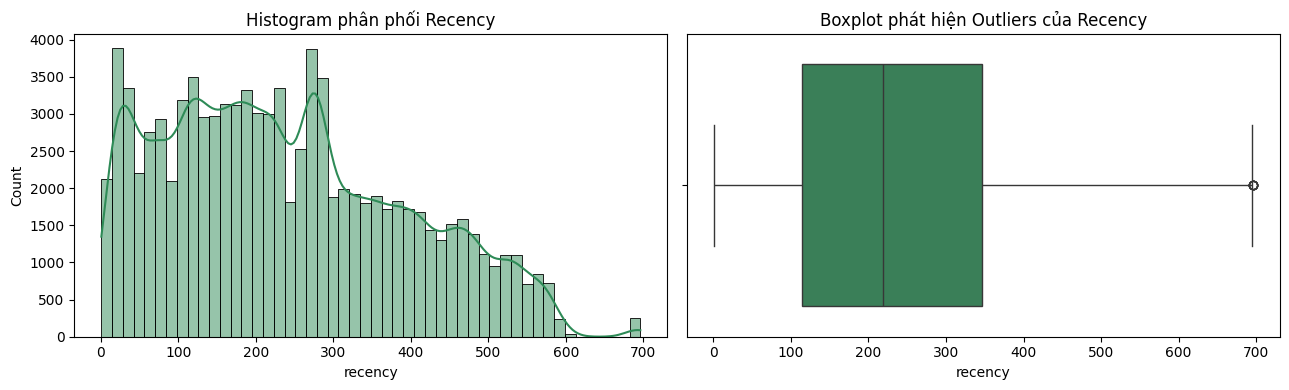

In [4]:
mo_ta_bien(rfm, 'recency')

**Observation**
- Phân bố khá đều trên toàn dải: Q1 = 115 ngày, trung vị 219 ngày, Q3 = 347 ngày, max 696 ngày.
- Trung bình (238) và trung vị (219) chênh nhau không đáng kể — biến này gần đối xứng,
  không có đuôi cực đoan như hai biến còn lại.

**Meaning**
- Recency là biến duy nhất trong ba chỉ số có khả năng phân biệt tốt trên toàn tập khách hàng.
- Trung vị 219 ngày cho thấy một nửa tập khách hàng đã không phát sinh giao dịch nào trong
  hơn 7 tháng — mức độ nguội lạnh của tệp khách rất cao.

**Action**
- Giữ nguyên thang đo gốc, không cần log transform.
- Đây sẽ là biến đóng vai trò chính trong việc tách cụm.

### 3.2. Frequency


--- THỐNG KÊ MÔ TẢ BIẾN FREQUENCY ---
count    93357.00
mean         1.02
std          0.18
min          1.00
25%          1.00
50%          1.00
75%          1.00
95%          1.00
99%          2.00
max         15.00


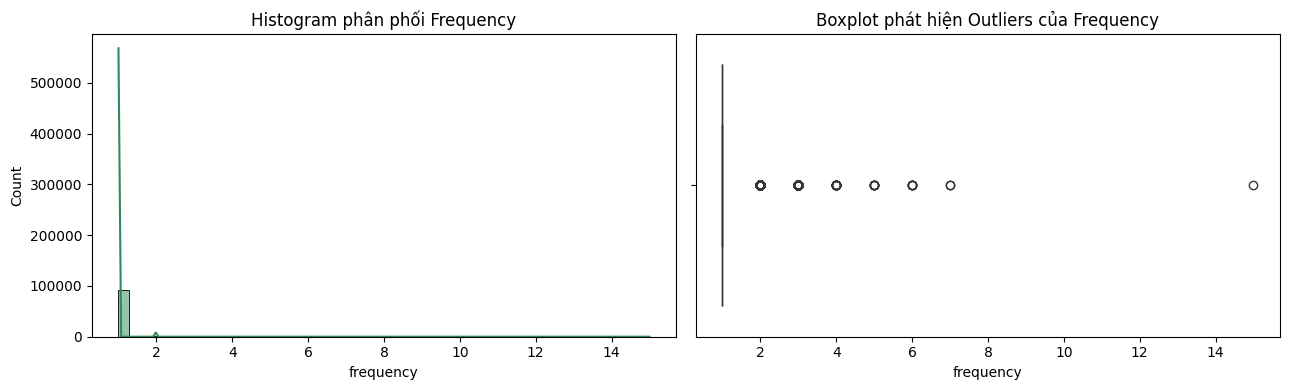

In [5]:
mo_ta_bien(rfm, 'frequency')

**Observation**
- Cả ba phân vị 25%, 50%, 75% đều bằng 1. Thậm chí phân vị 95% vẫn bằng 1.
- 91,342/93,357 khách hàng (97.8%) chỉ mua đúng một lần; chỉ 1,864 khách mua 2 lần và
  151 khách mua từ 3 lần trở lên. Giá trị lớn nhất là 15 lần.
- Frequency ở đây đếm số ngày mua riêng biệt. Nếu đếm theo `order_id` sẽ ra 2,801 khách mua lại
  (3.0%), nhưng 786 khách trong số đó chỉ có một lần checkout bị hệ thống tách thành nhiều
  `order_id` do giỏ hàng gồm sản phẩm của nhiều seller (các đơn này cách nhau median 1 giây —
  kiểm chứng ở notebook 02, phần 1).

**Meaning**
- Olist đang ở tình trạng "one-hit wonder": khách mua một lần rồi không quay lại, tỷ lệ
  giữ chân ở mức rất thấp. Đây là bài toán kinh doanh trung tâm của phân tích này.
- Về mặt kỹ thuật, không thể áp dụng phương pháp RFM truyền thống chia phân vị (`pd.qcut`)
  cho biến này: 97.8% giá trị trùng nhau tại 1 nên các mốc cắt 25%/50%/75% đều rơi vào cùng
  một giá trị, không tạo được ranh giới nhóm.
- Frequency gần như không mang thông tin phân biệt nên kết quả phân cụm sẽ chủ yếu do
  Recency và Monetary quyết định.

**Action**
- Sử dụng K-Means thay cho chấm điểm phân vị: K-means là thuật toán gom cụm theo khoảng cách hình học trong không gian ba chiều nên không phụ thuộc vào việc cắt ranh giới phân vị.
- Áp dụng log transform để nén khoảng cách giữa nhóm mua 1 lần và các giá trị ngoại lai
  (15 lần), tránh để thiểu số này chi phối tâm cụm.


### 3.3. Monetary

--- THỐNG KÊ MÔ TẢ BIẾN MONETARY ---
count    93357.00
mean       165.20
std        226.31
min          9.59
25%         63.06
50%        107.78
75%        182.56
95%        469.62
99%       1097.06
max      13664.08


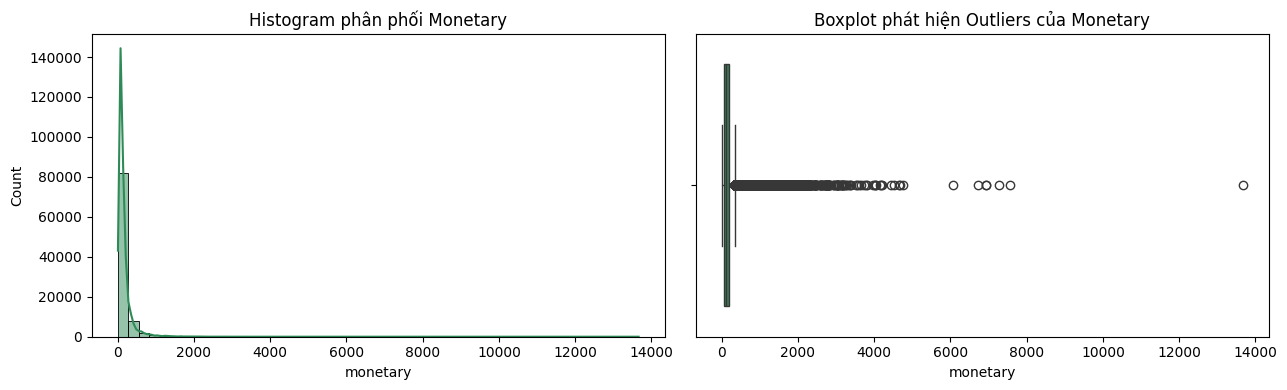

In [6]:
mo_ta_bien(rfm, 'monetary')

**Observation**
- Lệch phải rõ rệt: trung bình 165.20 BRL cao hơn trung vị 107.78 BRL.
- Khoảng cách giữa Q3 (182.56) và giá trị lớn nhất (13,664.08) là rất lớn; phân vị 99%
  mới chỉ ở mức 1,097 BRL.
- Nhóm 1% khách hàng chi tiêu cao nhất đóng góp tới 10.34% tổng doanh thu.

**Meaning**
- Nhóm khách chi tiêu lớn tuy rất ít nhưng đóng góp doanh thu đáng kể — đây có thể là khách
  mua sỉ hoặc mua sản phẩm giá trị cao, không phải lỗi dữ liệu, nên ta sẽ không loại bỏ khỏi phân tích.
- K-Means cực tiểu hóa tổng bình phương khoảng cách Euclid, nên nếu giữ nguyên thang đo gốc,
  các quan sát ở đuôi sẽ chi phối vị trí tâm cụm và kết quả nhiều khả năng là một cụm rất nhỏ
  tách riêng nhóm chi tiêu cao, phần còn lại gộp thành một khối không phân biệt được.

**Action**
- Giữ toàn bộ khách hàng, xử lý bằng log transform thay vì cắt bỏ outlier để giảm độ lệch dữ liệu mà không làm mất đi nhóm khách VIP có giá trị cao đột biến.
- Sau log transform, chuẩn hóa cả ba biến bằng StandardScaler để mô hình đánh giá công bằng R, F, M, tránh bị chi phối bởi các con số quá lớn của cột tiền (Monetary).

## 4. Xử lí và Chuẩn hóa dữ liệu 

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
rfm_log = rfm[['recency','frequency','monetary']].copy()
rfm_log[['frequency','monetary']] = np.log1p(rfm_log[['frequency','monetary']])   # chỉ log 2 biến lệch phải

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)     # scale cả 3 chiều

In [8]:
rfm_scaled.shape 

(93357, 3)

## 5. Lựa chọn số cụm 

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels, sample_size=10000, random_state=42))

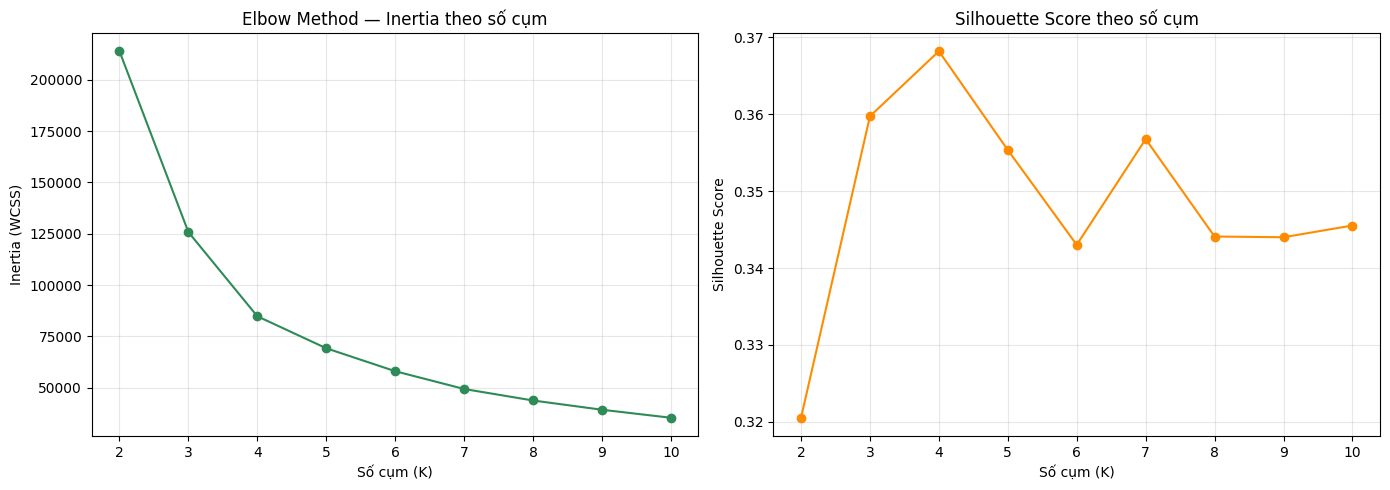

K=2   inertia=     213,968   silhouette=0.3205
K=3   inertia=     125,816   silhouette=0.3597
K=4   inertia=      84,810   silhouette=0.3682
K=5   inertia=      69,221   silhouette=0.3554
K=6   inertia=      58,039   silhouette=0.3430
K=7   inertia=      49,377   silhouette=0.3568
K=8   inertia=      43,768   silhouette=0.3441
K=9   inertia=      39,262   silhouette=0.3440
K=10  inertia=      35,356   silhouette=0.3455


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='seagreen')
axes[0].set_title('Elbow Method — Inertia theo số cụm')
axes[0].set_xlabel('Số cụm (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(alpha=.3)

axes[1].plot(K_range, silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score theo số cụm')
axes[1].set_xlabel('Số cụm (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

# In kèm số để đọc 
for k, i, s in zip(K_range, inertias, silhouettes):
    print(f"K={k:<3} inertia={i:>12,.0f}   silhouette={s:.4f}")

**Observation**
- Silhouette score dao động trong khoảng 0.32–0.37 trên toàn dải K=2 đến K=10, cao nhất tại
  K=4 (0.3682), thấp nhất tại K=2 (0.3205). Không giá trị K nào vượt trội.
- Đường inertia giảm nhanh đến K=4–5, sau đó mức giảm giữa các K liên tiếp thu hẹp dần —
  điểm gấp khúc nằm trong khoảng K=4 đến K=6.

**Meaning**
- Silhouette thấp ở K=2 cho thấy chia đôi theo Recency hoặc Monetary không tạo ra hai khối
  tách bạch; nhóm mua lặp lại (2.2% khách) quá nhỏ để tự thành một nửa của phép chia đôi.
- Từ K=3 trở đi các phương án tương đương nhau về mặt thống kê (chênh lệch silhouette dưới
  0.03). Các chỉ số nội tại chỉ đủ để khoanh vùng, không đủ để chọn ra một giá trị k duy nhất.

**Action**
- Khoanh vùng ứng viên: **K ∈ {4, 5, 6}**. Chuyển sang bước đánh giá theo tiêu chí kinh doanh
  để chọn giá trị cuối cùng.


In [11]:
for k in [4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    tmp = rfm.copy()
    tmp['cluster'] = km.fit_predict(rfm_scaled)
    print(f"\n===== K = {k} =====")
    print(tmp.groupby('cluster').agg(
        so_khach=('recency','size'),
        recency_tb=('recency','mean'),
        frequency_tb=('frequency','mean'),
        monetary_tb=('monetary','mean'),
        doanh_thu=('monetary','sum')
    ).round(1))


===== K = 4 =====
         so_khach  recency_tb  frequency_tb  monetary_tb  doanh_thu
cluster                                                            
0           28138       174.9           1.0        320.0  9003735.1
1           27284       426.1           1.0        120.3  3282896.4
2            2015       192.1           2.1        320.8   646454.2
3           35920       148.4           1.0         69.3  2489376.0

===== K = 5 =====
         so_khach  recency_tb  frequency_tb  monetary_tb  doanh_thu
cluster                                                            
0           28997       129.5           1.0        171.1  4962690.7
1            2015       192.1           2.1        320.8   646454.2
2           24470       422.4           1.0         95.9  2347380.1
3           12157       306.0           1.0        498.3  6058323.1
4           25718       158.1           1.0         54.7  1407613.6

===== K = 6 =====
         so_khach  recency_tb  frequency_tb  monetary_tb  d

**Observation**
- Cụm 2,015 khách mua lặp lại xuất hiện với chỉ số giống hệt nhau ở cả K=4, 5 và 6
  (recency 192.1 — frequency 2.1 — monetary 320.8): đây là một phân khúc tự nhiên, ổn định.
- K=4 gộp toàn bộ khách chi tiêu cao vào một cụm duy nhất (28,138 khách, 58.4% doanh thu,
  recency trung bình 174.9 ngày).
- K=5 tách cụm này thành hai: nhóm mới mua gần đây (28,997 khách, 32.2% doanh thu) và nhóm
  chi tiêu cao đã ngừng mua khoảng 10 tháng (12,157 khách — 13.0% số khách nhưng 39.3%
  doanh thu).
- K=6 chia nhỏ thêm ở nhóm giá trị thấp: hai cụm khách đã ngừng mua (380 và 434 ngày) và hai
  cụm khách mới mua chênh nhau chủ yếu về mức chi tiêu (54 và 153 BRL).

**Meaning**
- Ranh giới giữa "chi tiêu cao còn hoạt động" và "chi tiêu cao đã ngừng mua" là ranh giới có
  giá trị nhất: hai nhóm này cần chiến lược trái ngược nhau — bán thêm với nhóm thứ nhất, giữ
  chân khẩn cấp với nhóm thứ hai. K=4 xóa mất ranh giới này.
- Các cụm tăng thêm ở K=6 không dẫn tới hành động khác biệt: hai nhóm đã ngừng mua đều thuộc
  diện hạn chế chi ngân sách, hai nhóm mới mua đều thuộc diện nuôi dưỡng chuyển đổi. Việc tách
  thêm sẽ chỉ làm phức tạp hơn mà không tăng giá trị sử dụng.

**Action**
- Chọn **K = 5** cho mô hình chính thức.


**Hạn chế** : do 97.8% khách chỉ mua một lần, Frequency gần như không tham gia vào việc phân tách. Các cụm thực chất được hình thành bởi Recency và Monetary, ngoại trừ cụm khách mua lặp lại vốn đã tách biệt sẵn từ đầu


## 6. Phân cụm K-means và diễn giải

In [12]:
# Mô hình chính thức: K = 5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# Bảng đặc trưng từng cụm
profile = rfm.groupby('cluster').agg(
    so_khach=('recency', 'size'),
    recency_tb=('recency', 'mean'),
    frequency_tb=('frequency', 'mean'),
    monetary_tb=('monetary', 'mean'),
    doanh_thu=('monetary', 'sum')
)

profile['pct_khach'] = profile['so_khach'] / profile['so_khach'].sum() * 100
profile['pct_doanh_thu'] = profile['doanh_thu'] / profile['doanh_thu'].sum() * 100

profile = profile[['so_khach', 'pct_khach', 'recency_tb', 'frequency_tb',
                   'monetary_tb', 'doanh_thu', 'pct_doanh_thu']].round(1)

# Sắp xếp theo đóng góp doanh thu để dễ đọc thứ tự ưu tiên
profile = profile.sort_values('pct_doanh_thu', ascending=False)
profile

,so_khach,pct_khach,recency_tb,frequency_tb,monetary_tb,doanh_thu,pct_doanh_thu
cluster,,,,,,,
3,12157,13.0,306.0,1.0,498.3,6058323.1,39.3
0,28997,31.1,129.5,1.0,171.1,4962690.7,32.2
2,24470,26.2,422.4,1.0,95.9,2347380.1,15.2
4,25718,27.5,158.1,1.0,54.7,1407613.6,9.1
1,2015,2.2,192.1,2.1,320.8,646454.2,4.2


In [13]:
# Gán tên phân khúc theo ĐẶC TRƯNG của cụm, không theo số cụm:
# số cụm K-Means đổi mỗi khi dữ liệu đầu vào đổi, đặc trưng thì không.
prof = rfm.groupby('cluster').agg(
    recency_tb=('recency', 'mean'),
    frequency_tb=('frequency', 'mean'),
    monetary_tb=('monetary', 'mean'),
)

segment_map = {}
remaining = prof.copy()

# 1. Repeat Buyers: cụm duy nhất có frequency trung bình > 1
c = remaining['frequency_tb'].idxmax(); segment_map[c] = 'Repeat Buyers';       remaining = remaining.drop(c)
# 2. Lost: recency lớn nhất trong các cụm còn lại
c = remaining['recency_tb'].idxmax();   segment_map[c] = 'Lost';                remaining = remaining.drop(c)
# 3. At Risk: monetary lớn nhất trong các cụm còn lại
c = remaining['monetary_tb'].idxmax();  segment_map[c] = 'At Risk';             remaining = remaining.drop(c)
# 4. Potential Loyalist: monetary cao hơn trong hai cụm cuối; cụm còn lại là Low-Value Occasional
c = remaining['monetary_tb'].idxmax();  segment_map[c] = 'Potential Loyalist';  remaining = remaining.drop(c)
segment_map[remaining.index[0]] = 'Low-Value Occasional'

rfm['segment_name'] = rfm['cluster'].map(segment_map)

# Nghiệm thu: tên phải khớp đặc trưng trước khi ghi xuống DB
print(segment_map)
rfm.groupby('segment_name').agg(
    so_khach=('recency', 'size'),
    recency_tb=('recency', 'mean'),
    frequency_tb=('frequency', 'mean'),
    monetary_tb=('monetary', 'mean'),
).round(1).sort_values('monetary_tb', ascending=False)


{1: 'Repeat Buyers', 2: 'Lost', 3: 'At Risk', 0: 'Potential Loyalist', 4: 'Low-Value Occasional'}


,so_khach,recency_tb,frequency_tb,monetary_tb
segment_name,,,,
At Risk,12157,306.0,1.0,498.3
Repeat Buyers,2015,192.1,2.1,320.8
Potential Loyalist,28997,129.5,1.0,171.1
Lost,24470,422.4,1.0,95.9
Low-Value Occasional,25718,158.1,1.0,54.7


### Đặt tên phân khúc

Tên gọi được đặt dựa trên đặc trưng R-F-M của từng cụm và hành động marketing tương ứng.
Việc gán tên làm theo đặc trưng (cụm có frequency cao nhất là Repeat Buyers, cụm có recency
cao nhất trong phần còn lại là Lost, v.v.) chứ không theo số thứ tự cụm, vì K-Means đánh số
cụm khác nhau mỗi khi dữ liệu đầu vào thay đổi.

| Cụm | Tên phân khúc | Đặc trưng | Căn cứ đặt tên |
| :-- | :-- | :-- | :-- |
| 3 | **At Risk** | 306 ngày — 1 lần mua — 498.3 BRL<br>13.0% khách / **39.3% doanh thu** | Nhóm chi tiêu cao nhất nhưng đã ngừng mua khoảng 10 tháng. Mức đóng góp doanh thu lớn khiến đây là phân khúc ưu tiên số một |
| 0 | **Potential Loyalist** | 129.5 ngày — 1 lần mua — 171.1 BRL<br>31.1% khách / 32.2% doanh thu | Nhóm gần đây nhất và có mức chi khá. Chưa quay lại lần hai nhưng có tiềm năng chuyển đổi thành khách lặp lại |
| 2 | **Lost** | 422.4 ngày — 1 lần mua — 95.9 BRL<br>26.2% khách / 15.2% doanh thu | Đã ngừng mua gần 14 tháng với giá trị thấp, khả năng kích hoạt lại rất thấp |
| 4 | **Low-Value Occasional** | 158.1 ngày — 1 lần mua — 54.7 BRL<br>27.5% khách / 9.1% doanh thu | Chiếm hơn một phần tư số khách nhưng chỉ đóng góp 9.1% doanh thu. Giá trị đơn hàng thấp nhất trong toàn bộ cả 5 phân khúc |
| 1 | **Repeat Buyers** | 192.1 ngày — 2.1 lần mua — 320.8 BRL<br>2.2% khách / 4.2% doanh thu | Nhóm duy nhất mua lặp lại, tách biệt ổn định ở mọi giá trị K đã thử nhưng nhóm này cũng đã nguội hơn 6 tháng |

**Hai nhận xét quan trọng về kết quả đặt tên:**

1. **Không tồn tại phân khúc "Champions".** Dữ liệu không sinh ra nhóm nào vừa mua gần đây,
   vừa mua nhiều lần, vừa chi tiêu cao. Đây không phải giới hạn của mô hình mà là đặc điểm
   của doanh nghiệp: Olist chưa hình thành được tầng khách hàng trung thành có giá trị.

2. **Không tồn tại phân khúc "New Customers".** Cụm gần đây nhất cũng đã 130 ngày không phát
   sinh giao dịch. Vì vậy không nhóm nào phù hợp với các chiến dịch dành cho khách mới
   (welcome series, hướng dẫn sử dụng); mọi phân khúc đều cần tiếp cận theo hướng kích hoạt
   lại hoặc giữ chân.


## 7. Đối chiếu với phương pháp chấm điểm RFM truyền thống

In [14]:
# Chấm điểm RFM theo phương pháp truyền thống (thang điểm tương đối so với toàn tập khách hàng)

# R: chia 4 phân vị, gán nhãn NGƯỢC chiều — recency càng thấp (mua càng gần đây) điểm càng cao
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1]).astype(int)

# M: chia 4 phân vị, gán nhãn THUẬN chiều — chi tiêu càng nhiều điểm càng cao
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

# F: không dùng qcut được vì 97.8% giá trị bằng 1 (các mốc phân vị trùng nhau, không cắt được).
# Thay bằng ngưỡng rời rạc theo phân phối thực tế: 1 lần mua / 2 lần mua / từ 3 lần trở lên
rfm['f_score'] = pd.cut(rfm['frequency'], bins=[0, 1, 2, float('inf')], labels=[1, 2, 3]).astype(int)

In [15]:
# Kiểm chứng: điểm số phải phản ánh đúng đặc trưng của các phân khúc đã đặt tên
rfm.groupby('segment_name')[['r_score','f_score','m_score']].mean().round(2)

,r_score,f_score,m_score
segment_name,,,
At Risk,1.95,1.00,3.97
Lost,1.23,1.00,2.12
Low-Value Occasional,3.05,1.00,1.36
Potential Loyalist,3.30,1.00,3.14
Repeat Buyers,2.83,2.07,3.54


In [16]:
#Tổng điểm RFM — cách xếp hạng khách hàng phổ biến của phương pháp truyền thống
rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']
rfm.groupby('segment_name')['rfm_total'].mean().round(2).sort_values(ascending=False)

segment_name
Repeat Buyers           8.44
Potential Loyalist      7.43
At Risk                 6.92
Low-Value Occasional    5.41
Lost                    4.36
Name: rfm_total, dtype: float64

**Đối chiếu với phương pháp chấm điểm RFM truyền thống**

**Observation**
- Chấm điểm theo phân vị cho R và M (thang 1–4), theo ngưỡng rời rạc cho F (thang 1–3),
  tổng điểm RFM trung bình của các phân khúc như sau:

| Phân khúc | R | F | M | Tổng |
| :-- | --: | --: | --: | --: |
| Repeat Buyers | 2.83 | 2.07 | 3.54 | 8.44 |
| Potential Loyalist | 3.30 | 1.00 | 3.14 | 7.43 |
| At Risk | 1.95 | 1.00 | 3.97 | 6.92 |
| Low-Value Occasional | 3.05 | 1.00 | 1.36 | 5.41 |
| Lost | 1.23 | 1.00 | 2.12 | 4.36 |

- Bảng điểm xác nhận kết quả phân cụm: Potential Loyalist có điểm R cao nhất, Lost thấp nhất,
  Repeat Buyers là nhóm duy nhất có điểm F trên 1.
- Tuy nhiên, tổng điểm của Potential Loyalist (7.43) và At Risk (6.92) chỉ chênh nhau 0.51
  điểm trên thang 11 — chưa tới nửa điểm.

**Meaning**
- Việc cộng ba chỉ số thành một điểm duy nhất cho phép điểm Monetary cao bù đắp cho điểm
  Recency thấp. Kết quả là hai nhóm có hành vi trái ngược nhau lại nhận mức xếp hạng gần như
  tương đương: một nhóm chi trung bình 498 BRL rồi ngừng mua khoảng 10 tháng, nhóm kia chi 171 BRL
  và vừa mua cách đây 4 tháng.
- Hai phân khúc này chiếm 44.1% số khách hàng và 71.5% tổng doanh thu. Nếu phân khúc bằng
  tổng điểm RFM, phần lớn giá trị của tệp khách hàng sẽ được xử lý bằng cùng một chiến lược.
- K-Means phân tách được hai nhóm này vì thuật toán làm việc trên vị trí của từng khách hàng
  trong không gian ba chiều, thay vì nén ba chiều thành một giá trị vô hướng.

**Action**
- Sử dụng kết quả phân cụm K-Means làm cơ sở phân khúc chính thức.
- Giữ lại ba cột điểm R, F, M trong bảng kết quả để phục vụ lọc và đối chiếu trên báo cáo
  Power BI, đồng thời làm tham chiếu cho người quen với thang điểm RFM truyền thống.


## 8. Ghi kết quả xuống Data Warehouse

In [17]:
from sqlalchemy import text

# Chuẩn bị DataFrame khớp đúng cấu trúc bảng gold.fact_rfm_segments
rfm_out = rfm.reset_index()[['customer_unique_id', 'recency', 'frequency', 'monetary',
                             'r_score', 'f_score', 'm_score', 'cluster', 'segment_name']].copy()
rfm_out = rfm_out.rename(columns={'cluster': 'cluster_id'})
rfm_out['snapshot_date'] = snapshot_date

# Xóa snapshot cùng kỳ nếu đã tồn tại — đảm bảo chạy lại notebook không nhân đôi dữ liệu
with engine.begin() as conn:
    conn.execute(
        text("DELETE FROM gold.fact_rfm_segments WHERE snapshot_date = :d"),
        {"d": snapshot_date}
    )

# Ghi kết quả phân cụm về data warehouse
rfm_out.to_sql('fact_rfm_segments', engine, schema='gold',
               if_exists='append', index=False)

print(f"Đã ghi {len(rfm_out):,} dòng với snapshot_date = {snapshot_date}")

Đã ghi 93,357 dòng với snapshot_date = 2018-08-30


In [18]:
# Nghiệm thu bằng SQL: đối chiếu số khách hàng và tổng giá trị với dữ liệu nguồn
pd.read_sql("""
    SELECT COUNT(*) AS so_khach,
           SUM(monetary) AS tong_gia_tri,
           COUNT(DISTINCT segment_name) AS so_phan_khuc
    FROM gold.fact_rfm_segments;
""", engine)

,so_khach,tong_gia_tri,so_phan_khuc
0,93357,15422461.77,5


## 9. Kết luận

**Cấu trúc tệp khách hàng.** 93,357 khách hàng được chia thành 5 phân khúc dựa trên hành vi
mua. Ba phân khúc chiếm phần lớn giá trị: At Risk (13.0% khách — 39.3% doanh thu),
Potential Loyalist (31.1% — 32.2%) và Lost (26.2% — 15.2%). Hai phân khúc còn lại là
Low-Value Occasional (27.5% — 9.1%) và Repeat Buyers (2.2% — 4.2%).

**Ba phát hiện chính:**

1. **Gần 40% doanh thu đến từ nhóm khách hàng đã ngừng mua.** Phân khúc At Risk gồm 12,157
   khách có mức chi trung bình 498.3 BRL — cao nhất toàn tập — nhưng đã không phát sinh giao
   dịch trong trung bình 306 ngày. Đây là phần giá trị lớn nhất đang có nguy cơ mất hẳn.

2. **Doanh nghiệp chưa hình thành được tầng khách hàng trung thành.** Không có phân khúc nào
   đạt đồng thời ba tiêu chí mua gần đây, mua nhiều lần và chi tiêu cao. Chỉ 2.2% khách hàng
   từng mua lần thứ hai, và ngay cả nhóm này cũng đã nguội hơn 6 tháng.

3. **Không có khách hàng mới trong tệp phân tích.** Phân khúc gần đây nhất cũng đã 130 ngày
   không quay lại. Toàn bộ tệp khách hàng đang ở trạng thái cần kích hoạt lại, không có nhóm
   nào phù hợp với các chương trình dành cho khách mới.

**Thứ tự ưu tiên hành động:**

1. *At Risk* — ưu tiên cao nhất do tỷ trọng doanh thu lớn. Cần chiến dịch giữ chân có mức đầu
   tư tương xứng với giá trị khách hàng.
2. *Potential Loyalist* — nhóm có triển vọng chuyển đổi thành khách lặp lại. Đây là hướng duy
   nhất để xây dựng tầng khách hàng trung thành mà doanh nghiệp đang thiếu.
3. *Repeat Buyers* — quy mô nhỏ nhưng là bằng chứng cho thấy khách hàng có thể quay lại. Cần
   phân tích sâu hơn đặc điểm nhóm này để nhân rộng.
4. *Low-Value Occasional* và *Lost* — hạn chế chi ngân sách, chỉ tiếp cận trong các chiến dịch
   quy mô lớn.

**Hạn chế của phân tích:**

- 97.8% khách hàng chỉ mua một lần khiến Frequency gần như không tham gia vào việc phân tách
  cụm; kết quả chủ yếu phản ánh Recency và Monetary.
- Dữ liệu không có chi phí marketing và giá vốn, nên Monetary là doanh thu chứ không phải lợi
  nhuận, và không thể đánh giá hiệu quả đầu tư của các chiến dịch đề xuất.
- Kết quả phản ánh trạng thái tại một thời điểm (30/08/2018). Việc đánh giá dịch chuyển giữa
  các phân khúc theo thời gian cần thêm ít nhất một kỳ phân tích nữa.
